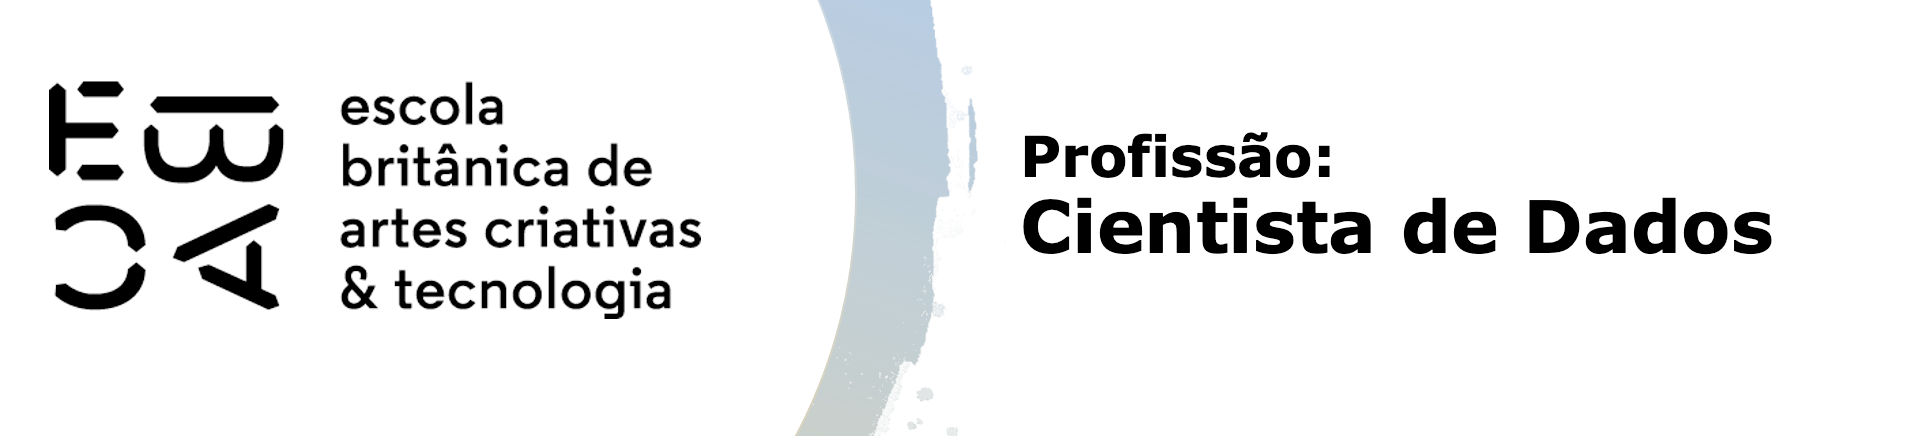

# Tarefa - Agrupamento hierárquico

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo agora é agrupar as sessões de acesso ao portal considerando o comportamento de acesso e informações da data, como a proximidade a uma data especial, fim de semana e o mês.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.sphinxext.mathmpl import math_role

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

from gower import gower_matrix
%matplotlib inline

In [84]:
df = pd.read_csv('online_shoppers_intention.csv')

In [85]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [86]:
df.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [87]:
df.shape

(12330, 18)

In [88]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [89]:
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [90]:
df.dropna()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [91]:
df.fillna

<bound method NDFrame.fillna of        Administrative  Administrative_Duration  Informational  \
0                   0                      0.0              0   
1                   0                      0.0              0   
2                   0                      0.0              0   
3                   0                      0.0              0   
4                   0                      0.0              0   
...               ...                      ...            ...   
12325               3                    145.0              0   
12326               0                      0.0              0   
12327               0                      0.0              0   
12328               4                     75.0              0   
12329               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                         0.0               1                 0.000000   
1                         0.0          

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

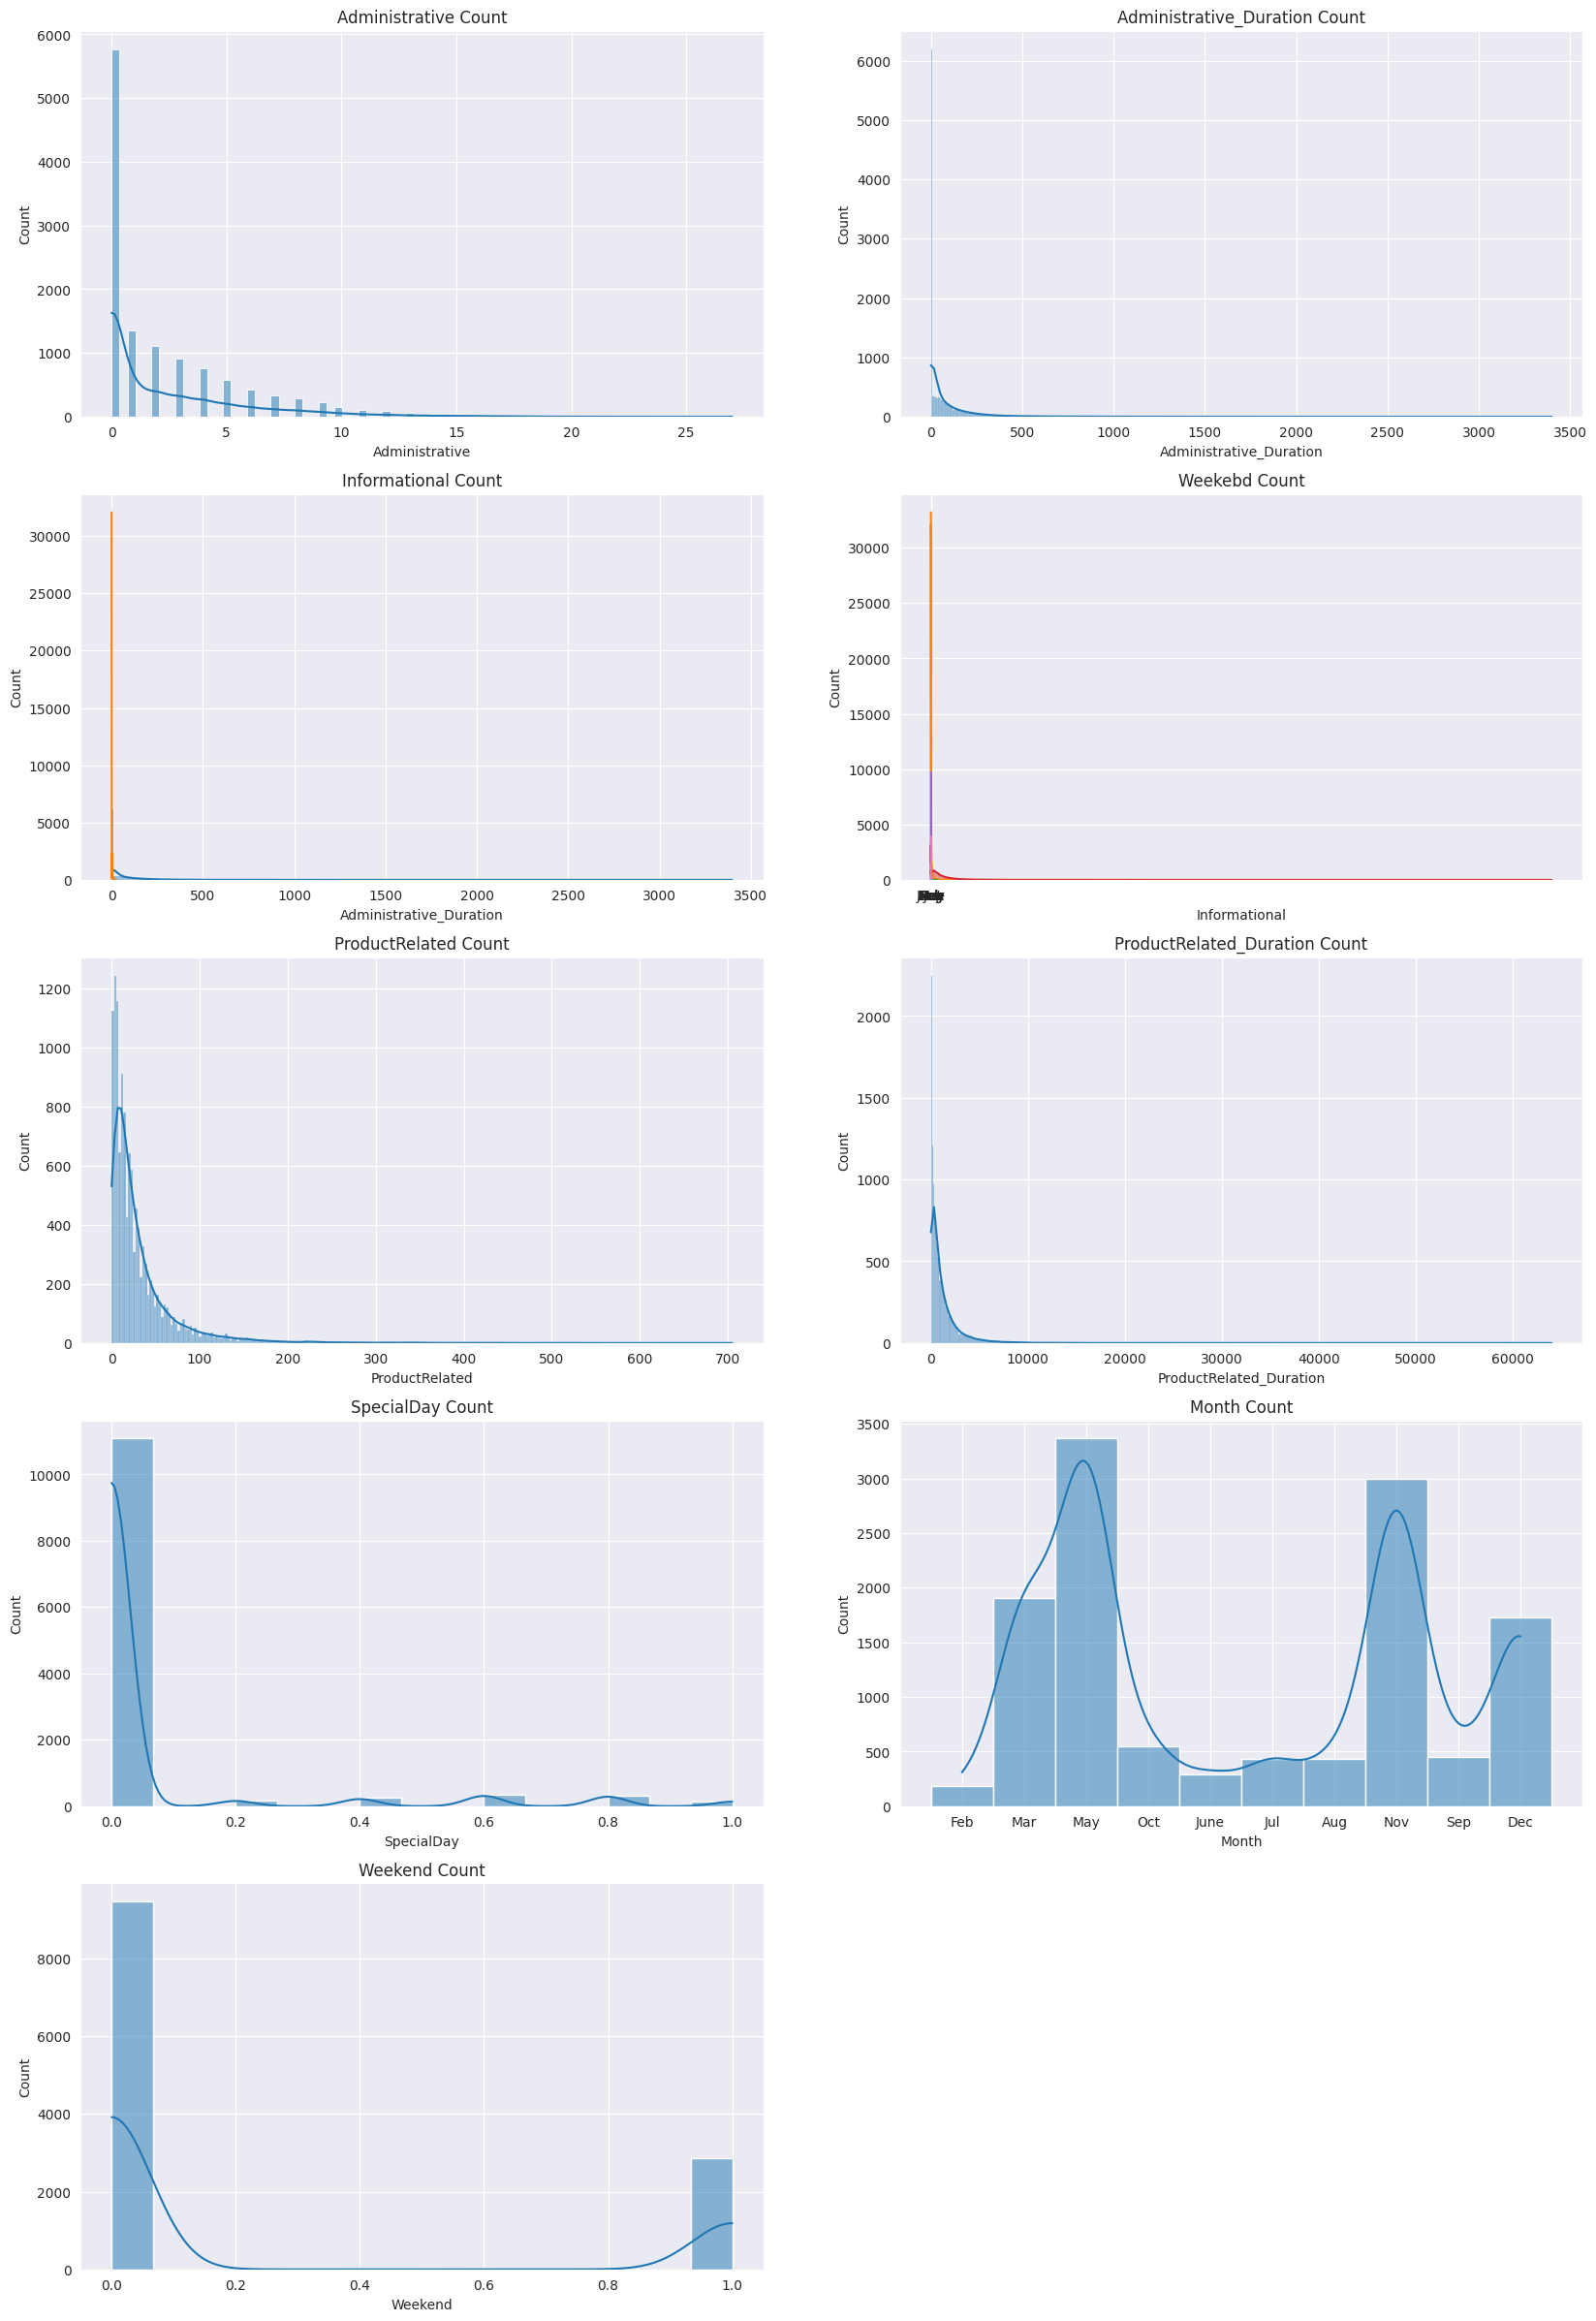

In [92]:
fig, axis = plt.subplots(5, 2, figsize=(20, 30))

sns.histplot(data=df, x="Administrative", kde=True, ax=axis[0, 0])
axis[0, 0].set_title('Administrative Count')

sns.histplot(data=df, x="Administrative_Duration", kde=True, ax=axis[1, 0])
sns.histplot(data=df, x="Administrative_Duration", kde=True, ax=axis[0, 1])
axis[1, 0].set_title('Administrative_Duration Count')
axis[0, 1].set_title('Administrative_Duration Count')

sns.histplot(data=df, x="Informational", kde=True, ax=axis[1, 1])
sns.histplot(data=df, x="Informational", kde=True, ax=axis[1, 0])
axis[1, 1].set_title('Informational Count')
axis[1, 0].set_title('Informational Count')

sns.histplot(data=df, x="Informational_Duration", kde=True, ax=axis[1, 1])
axis[1, 1].set_title('Informational_Duration Count')

sns.histplot(data=df, x="ProductRelated", kde=True, ax=axis[1, 1])
sns.histplot(data=df, x="ProductRelated", kde=True, ax=axis[2, 0])
axis[1, 1].set_title('ProductRelated Count')
axis[2, 0].set_title('ProductRelated Count')

sns.histplot(data=df, x="ProductRelated_Duration", kde=True, ax=axis[1, 1])
sns.histplot(data=df, x="ProductRelated_Duration", kde=True, ax=axis[2, 1])
axis[1, 1].set_title('ProductRelated_Duration Count')
axis[2, 1].set_title('ProductRelated_Duration Count')

sns.histplot(data=df, x="SpecialDay", kde=True, ax=axis[1, 1])
sns.histplot(data=df, x="SpecialDay", kde=True, ax=axis[3, 0])
axis[1, 1].set_title('SpecialDay Count')
axis[3, 0].set_title('SpecialDay Count')

sns.histplot(data=df, x="Month", kde=True, ax=axis[1, 1])
sns.histplot(data=df, x="Month", kde=True, ax=axis[3, 1])
axis[1, 1].set_title('Month Count')
axis[3, 1].set_title('Month Count')

sns.histplot(data=df, x="Weekend", kde=True, ax=axis[1, 1])
sns.histplot(data=df, x="Weekend", kde=True, ax=axis[4, 0])
axis[1, 1].set_title('Weekebd Count')
axis[4, 0].set_title('Weekend Count')


# Hide the last empty subplot
axis[4, 1].axis('off')



## Variáveis de agrupamento

Liste as variáveis que você vai querer utilizar. Essa é uma atividade importante do projeto, e tipicamente não a recebemos pronta. Não há resposta pronta ou correta, mas apenas critérios e a sua decisão. Os critérios são os seguintes:

- Selecione para o agrupamento variáveis que descrevam o padrão de navegação na sessão.
- Selecione variáveis que indiquem a característica da data.
- Não se esqueça de que você vai precisar realizar um tratamento especial para variáveis qualitativas.
- Trate adequadamente valores faltantes.

In [93]:
variaveis = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
             'ProductRelated', 'ProductRelated_Duration', 'SpecialDay', 'Month', 'Weekend']

variaveis_qtd = ['Administrative', 'Administrative_Duration', 'Informational',
                 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']

variaveis_cat = ['SpecialDay', 'Month', 'Weekend']


In [94]:
df_padrao = pd.DataFrame(StandardScaler().fit_transform(df[variaveis_qtd]), columns=df[variaveis_qtd].columns)
df_padrao[variaveis_cat] = df[variaveis_cat]
df_padrao.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay,Month,Weekend
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,0.0,Feb,False
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,0.0,Feb,False
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,0.0,Feb,False
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.0,Feb,False
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,0.0,Feb,True


In [95]:
df_tratado = pd.get_dummies(df_padrao[variaveis].dropna(), columns=variaveis_cat)
df_tratado.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,SpecialDay_0.0,SpecialDay_0.2,SpecialDay_0.4,SpecialDay_0.6,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,Weekend_False,Weekend_True
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True


In [96]:
df_tratado.columns.values

array(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'SpecialDay_0.0', 'SpecialDay_0.2',
       'SpecialDay_0.4', 'SpecialDay_0.6', 'SpecialDay_0.8',
       'SpecialDay_1.0', 'Month_Aug', 'Month_Dec', 'Month_Feb',
       'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov',
       'Month_Oct', 'Month_Sep', 'Weekend_False', 'Weekend_True'],
      dtype=object)

## Número de grupos

Nesta atividade vamos adotar uma abordagem bem pragmática e avaliar agrupamentos hierárquicos com 3 e 4 grupos, por estarem bem alinhados com uma expectativa e estratégia do diretor da empresa. 

*Atenção*: Cuidado se quiser fazer o dendrograma, pois com muitas observações ele pode ser mais complicado de fazer, e dependendo de como for o comando, ele pode travar o *kernell* do seu python.

In [97]:
vars_cat = [True if x in {
    'SpecialDay_0.0', 'SpecialDay_0.2', 'SpecialDay_0.4', 'SpecialDay_0.6', 'SpecialDay_0.8',
    'SpecialDay_1.0', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June',
    'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'Weekend_False', 'Weekend_True'
} else False for x in df_tratado.columns]

In [98]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  float64
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  float64
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  float64
 5   ProductRelated_Duration  12330 non-null  float64
 6   SpecialDay_0.0           12330 non-null  bool   
 7   SpecialDay_0.2           12330 non-null  bool   
 8   SpecialDay_0.4           12330 non-null  bool   
 9   SpecialDay_0.6           12330 non-null  bool   
 10  SpecialDay_0.8           12330 non-null  bool   
 11  SpecialDay_1.0           12330 non-null  bool   
 12  Month_Aug                12330 non-null  bool   
 13  Month_Dec                12330 non-null  bool   
 14  Month_Feb             

In [99]:
# calculando as distâncias
distancia_gower = gower_matrix(df_tratado, cat_features=vars_cat)

# ajustando a matriz de distâncias para alimentar o algoritmo com este objeto
gdv = squareform(distancia_gower, force='tovector')
gdv.shape

(76008285,)

In [100]:
Z = linkage(gdv, method='complete')


### Avaliação dos grupos

Construa os agrupamentos com a técnica adequada que vimos em aula. Não se esqueça de tratar variáveis qualitativas, padronizar escalas das quantitativas, tratar valores faltantes e utilizar a distância correta.

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

In [101]:
# Padronizar variáveis quantitativas
df_padronizado = pd.DataFrame(StandardScaler().fit_transform(df[variaveis_qtd]), columns=variaveis_qtd)
# Tratar variáveis qualitativas utilizando dummy encoding
df_padronizado = pd.concat([df_padronizado, pd.get_dummies(df[variaveis_cat])], axis=1)

In [102]:
# Calcular matriz de distância utilizando a métrica correta (Gower devido à presença de variáveis qualitativas e quantitativas)
distancia_gower = gower_matrix(df_padronizado)

In [103]:
# Ajustar a matriz de distâncias para o formato correto
gdv = squareform(distancia_gower, force='tovector')

In [104]:
# Construir o dendrograma usando Linkage com método de agrupamento hierárquico completo
Z = linkage(gdv, method='complete')

In [105]:
# Examinar duas soluções de agrupamentos com 3 e 4 grupos
for k in [3, 4]:
    # Criar o agrupamento hierárquico
    df_padronizado[f'grupo_{k}'] = fcluster(Z, k, criterion='maxclust')

    # Combinar com o dataframe original para descrições
    df_grupos = df.join(df_padronizado[f'grupo_{k}'], how='left')

    # Criar uma análise descritiva por grupo
    print(f"\nAnálise descritiva para {k} grupos:")
    print(df_grupos.groupby(f'grupo_{k}').agg({
        'BounceRates': ['mean', 'std'],
        'Revenue': 'sum',
        'Administrative': ['mean', 'std'],
        'ProductRelated': ['mean', 'std'],
    }))
    print(f"\nDistribuição dos grupos ({k} grupos):")
    print(df_grupos[f'grupo_{k}'].value_counts())


Análise descritiva para 3 grupos:
        BounceRates           Revenue Administrative           ProductRelated  \
               mean       std     sum           mean       std           mean   
grupo_3                                                                         
1          0.003644  0.002504       0      12.333333  6.429101     499.000000   
2          0.027918  0.053523     368       1.886947  2.985000      25.502678   
3          0.019884  0.046109    1540       2.484738  3.427922      34.088155   

                     
                std  
grupo_3              
1        186.107496  
2         30.649156  
3         47.903953  

Distribuição dos grupos (3 grupos):
grupo_3
3    8780
2    3547
1       3
Name: count, dtype: int64

Análise descritiva para 4 grupos:
        BounceRates           Revenue Administrative           ProductRelated  \
               mean       std     sum           mean       std           mean   
grupo_4                                         

In [108]:
df_grupos.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,grupo_4
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,2
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,2
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,2
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,2


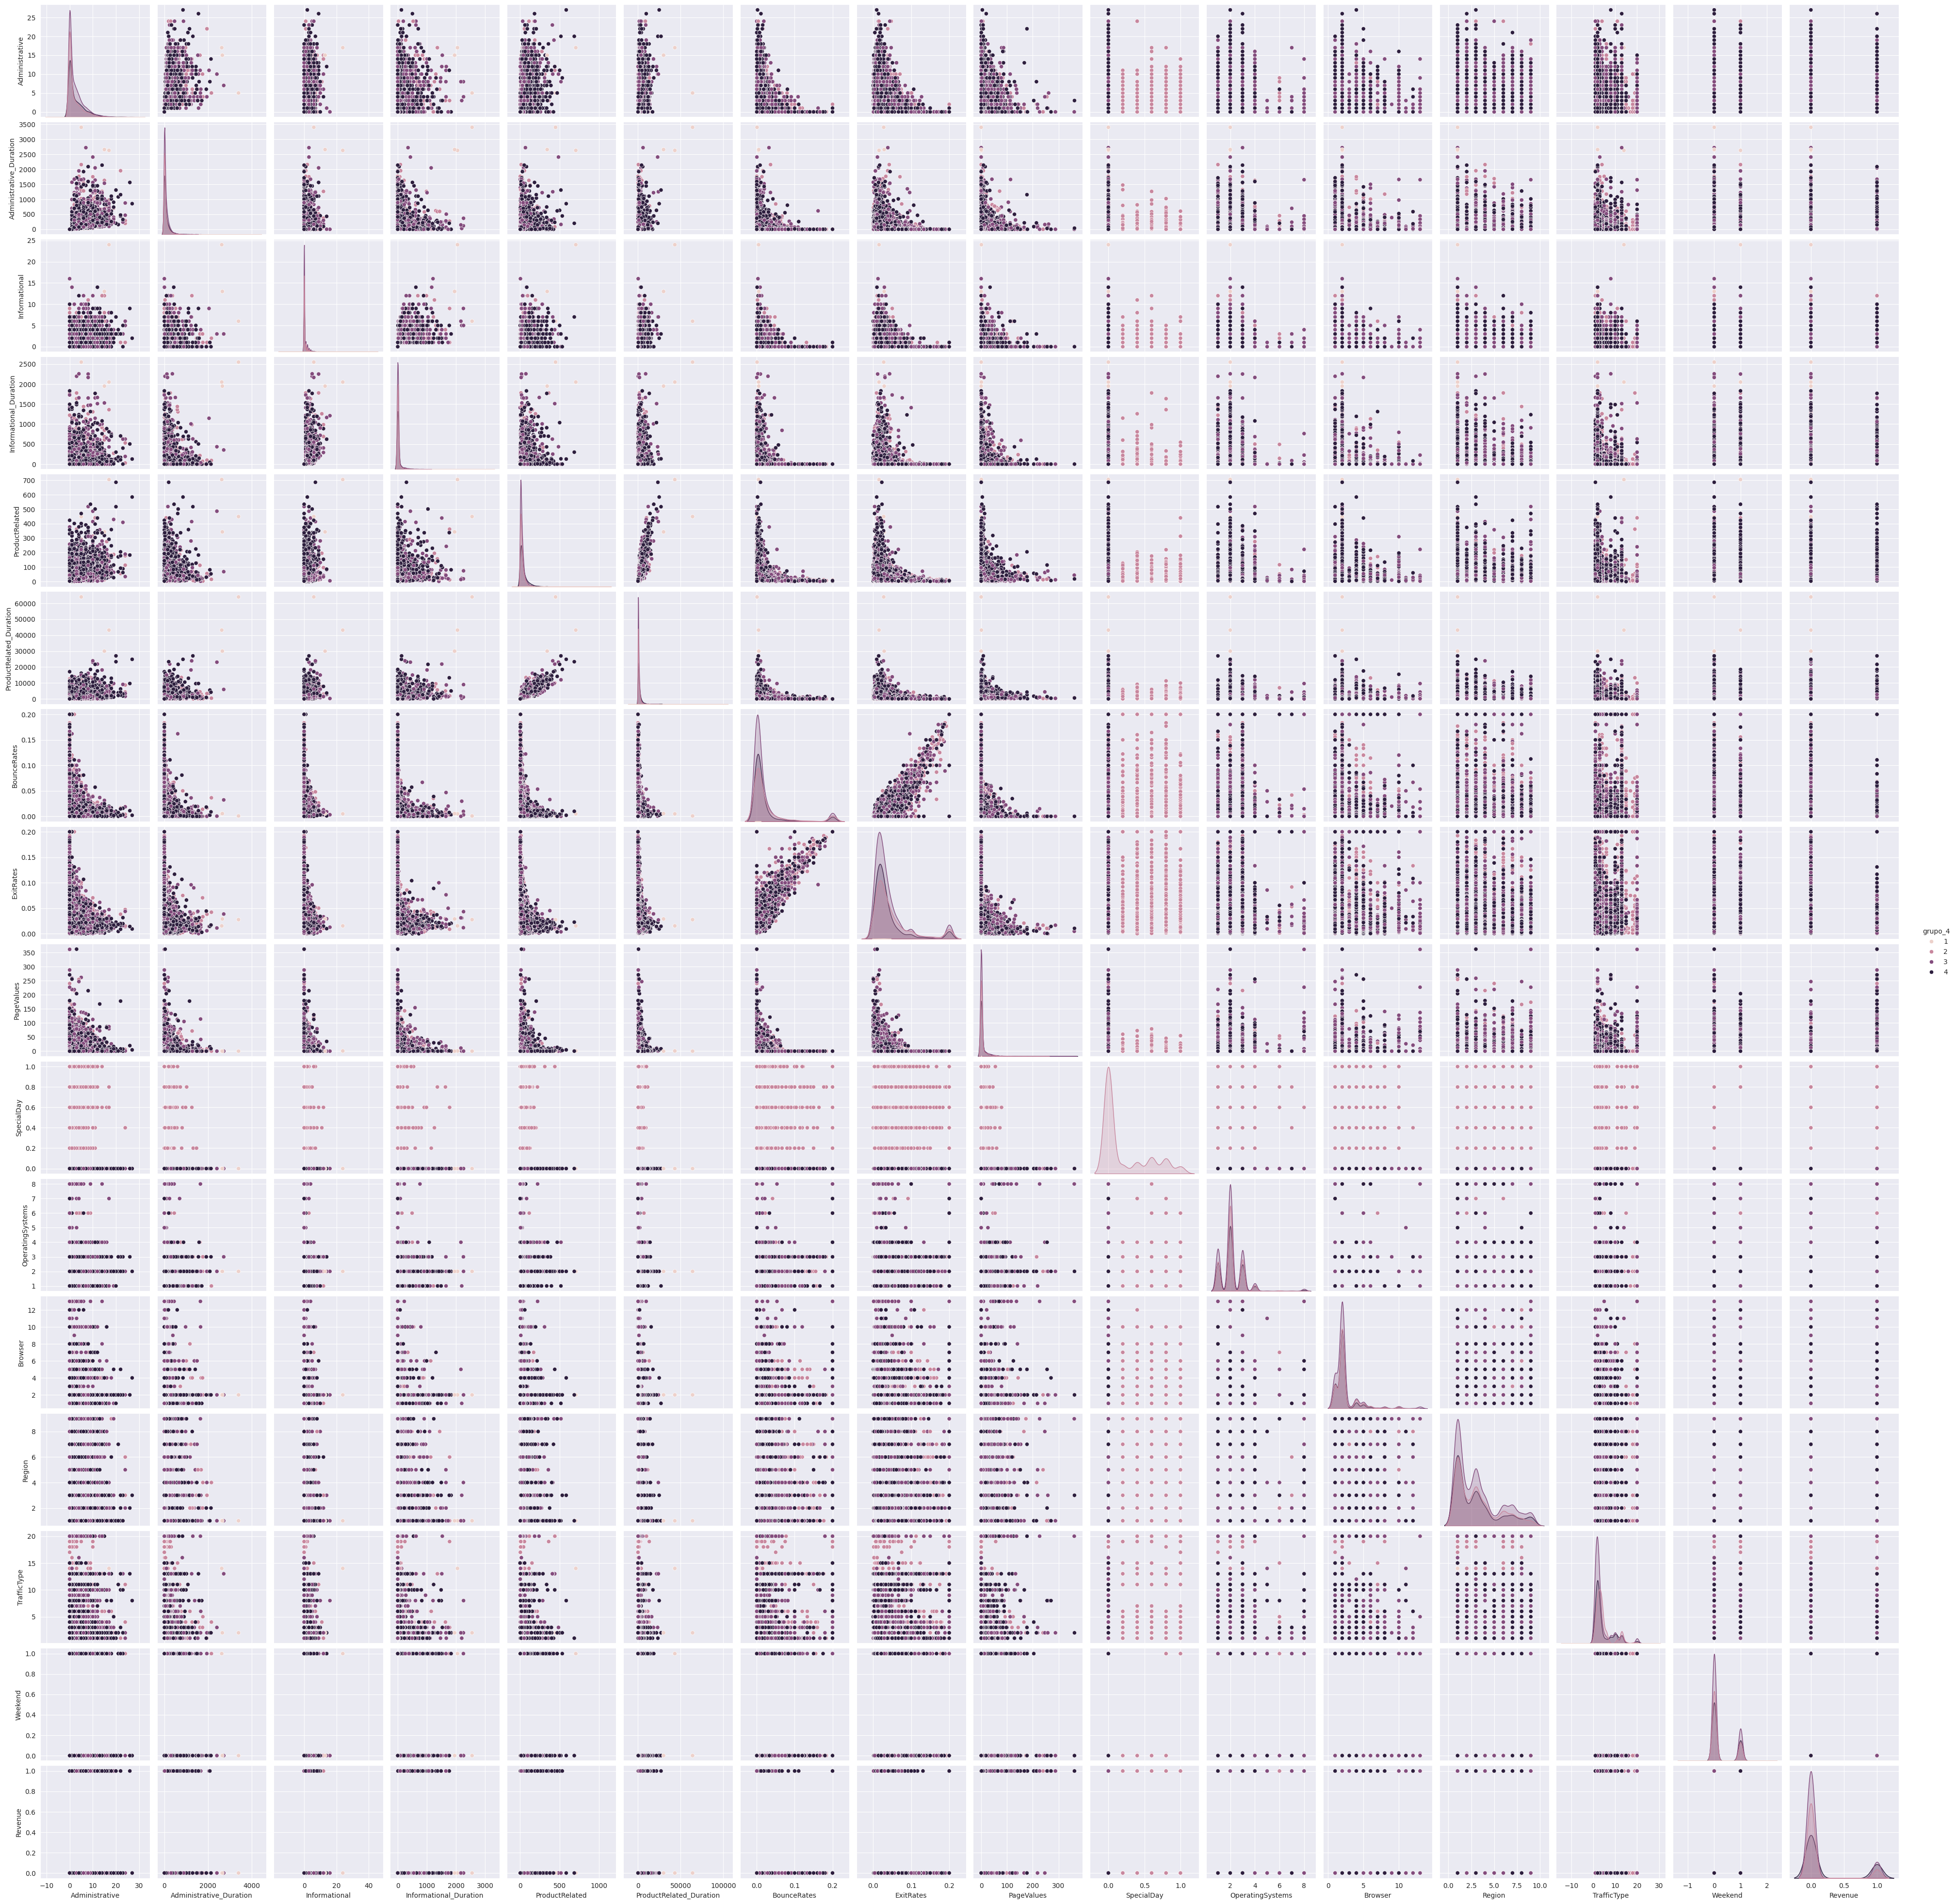

In [110]:
sns.pairplot(df_grupos, hue='grupo_4')

## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?


In [122]:
# Avaliação dos grupos em relação às variáveis 'BounceRates' e 'Revenue'

# Define the groups from previous clustering with 4 groups
grupo_coluna = 'grupo_4'

# Combine groups with the original data
df_avaliacao = df.join(df_padronizado[grupo_coluna])


In [123]:
# Calculate descriptive statistics for 'BounceRates' and 'Revenue' by group
avaliacao_grupos = df_avaliacao.groupby(grupo_coluna).agg({
    'BounceRates': ['mean', 'std'],  # Mean and standard deviation of BounceRates
    'Revenue': ['sum', 'mean'],      # Total and mean numbers of purchases (converted checks)
}).reset_index()



In [124]:
# Display results
print("Avaliação dos grupos em relação a 'BounceRates' e 'Revenue':")
print(avaliacao_grupos)

# Identifying the group more likely to make purchases based on mean 'Revenue'
grupo_mais_compras = avaliacao_grupos.loc[avaliacao_grupos[('Revenue', 'mean')].idxmax()]
print("\nGrupo mais propenso à compra:")
print(grupo_mais_compras)

Avaliação dos grupos em relação a 'BounceRates' e 'Revenue':
  grupo_4 BounceRates           Revenue          
                 mean       std     sum      mean
0       1    0.003644  0.002504       0  0.000000
1       2    0.027918  0.053523     368  0.103750
2       3    0.020370  0.047210     704  0.131613
3       4    0.019127  0.044334     836  0.243661

Grupo mais propenso à compra:
grupo_4                4.000000
BounceRates  mean      0.019127
             std       0.044334
Revenue      sum     836.000000
             mean      0.243661
Name: 3, dtype: float64
